In [1]:
# Libraries

In [4]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


In [ ]:
# Venn Diagram

In [2]:
import pandas as pd
from supervenn import supervenn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import os
from sklearn.metrics import auc

In [ ]:
# AUC plot

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# List of files to process
file_paths = [
    "../../PASNet/Output/REST/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/REST/roc_curve_data_BCMO_testing.txt",
    "../../PASNet/Output/GO/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/GO/roc_curve_data_BCMO_testing.txt"
]

# Plotting
plt.figure(figsize=(10, 8))

for file_path in file_paths:
    # Read the file (tab-separated, skipping comment lines)
    df = pd.read_csv(file_path, sep="\t", comment='#', names=["FPR", "TPR"])

    # Calculate AUC
    curve_auc = auc(df["FPR"], df["TPR"])

    # Generate label from file path
    method = os.path.basename(os.path.dirname(file_path))   # REST or GO
    dataset = os.path.splitext(os.path.basename(file_path))[0].replace("roc_curve_data_", "")
    label = f"{method} - {dataset} (AUC = {curve_auc:.2f})"

    # Plot the ROC curve with thicker line
    plt.plot(df["FPR"], df["TPR"], label=label, linewidth=3)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# Plot settings with larger labels and title
plt.xlabel("False Positive Rate", fontsize=22)
plt.ylabel("True Positive Rate", fontsize=22)
plt.title("ROC Curves with AUC", fontsize=26)
plt.legend(loc="lower right", fontsize=20, frameon=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig("../../figures/AUC_ROC.png", dpi=600)

# Display the plot
plt.show()


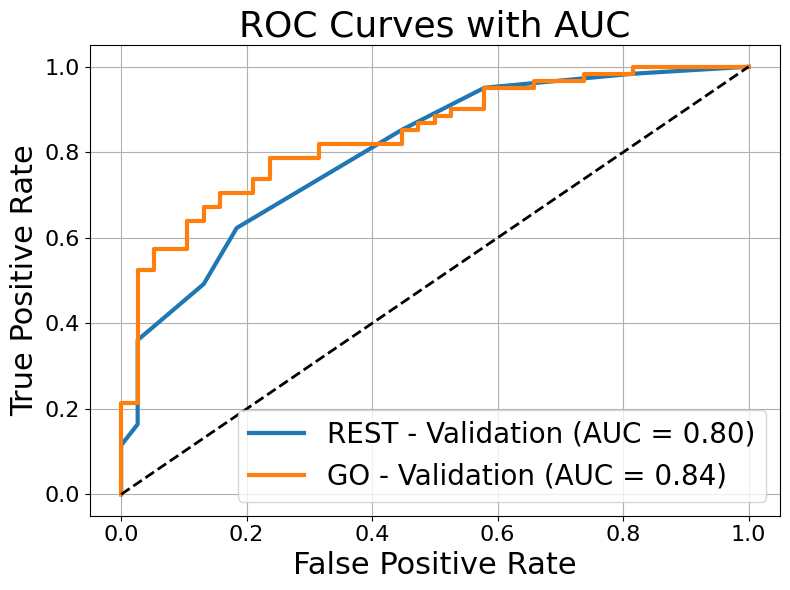

In [3]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# List of files to process
file_paths = [
    "../../PASNet/Output/REST/roc_curve_data_Validation.txt",
    "../../PASNet/Output/GO/roc_curve_data_Validation.txt",
]

# Plotting
plt.figure(figsize=(8, 6))

for file_path in file_paths:
    # Read the file (tab-separated, skipping comment lines)
    df = pd.read_csv(file_path, sep="\t", comment='#', names=["FPR", "TPR"])

    # Calculate AUC
    curve_auc = auc(df["FPR"], df["TPR"])

    # Generate label from file path
    method = os.path.basename(os.path.dirname(file_path))   # REST or GO
    dataset = os.path.splitext(os.path.basename(file_path))[0].replace("roc_curve_data_", "")
    label = f"{method} - {dataset} (AUC = {curve_auc:.2f})"

    # Plot the ROC curve with thicker line
    plt.plot(df["FPR"], df["TPR"], label=label, linewidth=3)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# Plot settings with larger labels and title
plt.xlabel("False Positive Rate", fontsize=22)
plt.ylabel("True Positive Rate", fontsize=22)
plt.title("ROC Curves with AUC", fontsize=26)
plt.legend(loc="lower right", fontsize=20, frameon=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig("../../figures/AUC_ROC.png", dpi=600)

# Display the plot
plt.show()


In [ ]:
# F1score

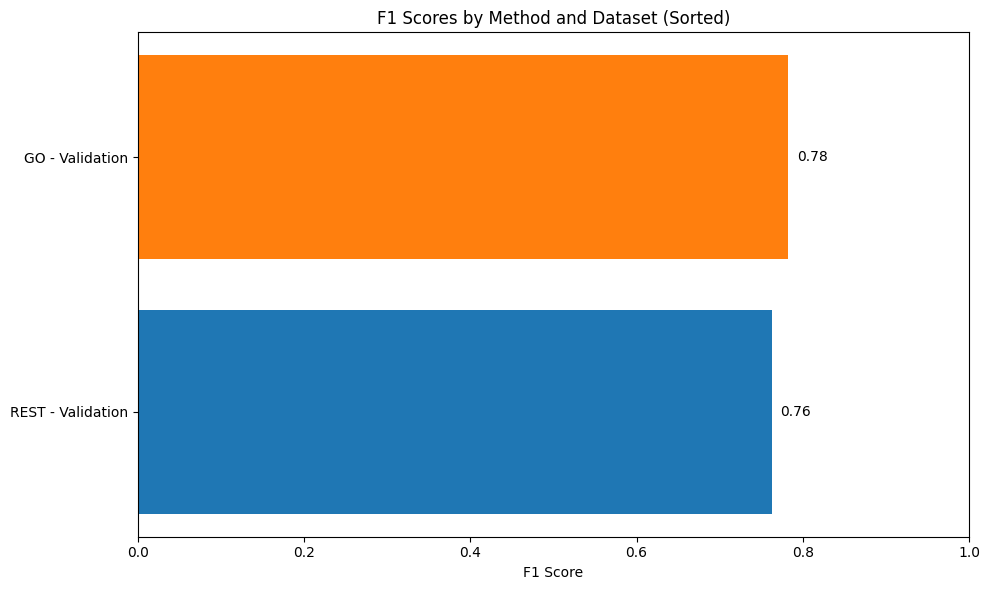

In [5]:
import matplotlib.pyplot as plt

# F1 score data
f1_scores = {
    "GO - Validation": 0.7826086956521739468,
    "REST - Validation": 0.7624999999999999556,
}

# Specific colors for each label
color_map = {
    "REST - Validation": "#1f77b4",  # Blue
    "GO - Validation": "#ff7f0e"     # Orange
}

# Sort by score descending
sorted_items = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)
labels = [item[0] for item in sorted_items]
scores = [item[1] for item in sorted_items]
colors = [color_map[label] for label in labels]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, scores, color=colors)

# Label each bar
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{score:.2f}", va='center', fontsize=10)

# Format
plt.xlim(0, 1)
plt.xlabel("F1 Score")
plt.title("F1 Scores by Method and Dataset (Sorted)")
plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()

# Save
plt.savefig("../../figures/f1_scores.png", dpi=600)

# Show
plt.show()

In [ ]:
# SHAP values

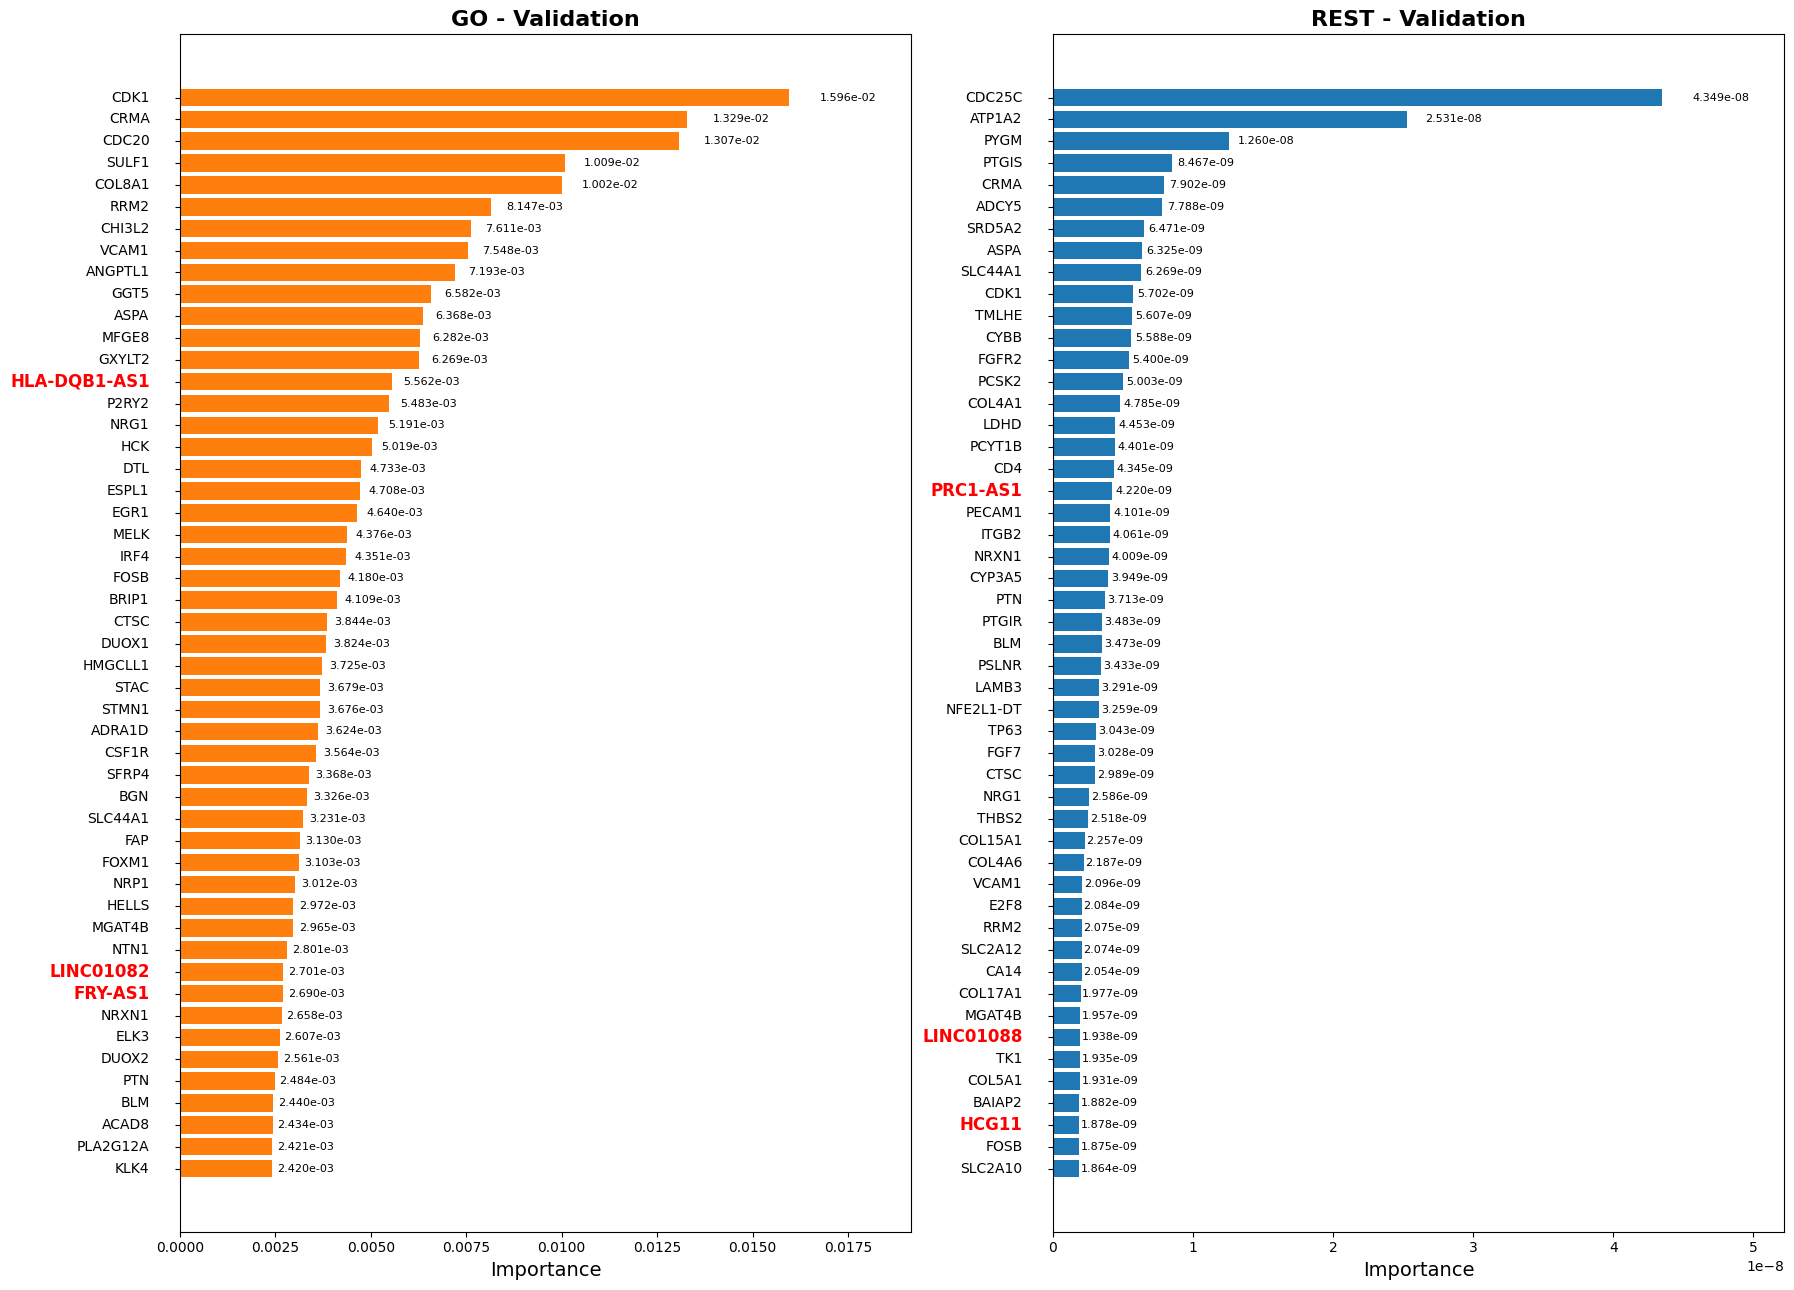

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

file_paths = {
    "GO - Validation": "../../PASNet/Output/GO/feature_importance_table.csv",
    "REST - Validation": "../../PASNet/Output/REST/feature_importance_table.csv"
}

color_map = {
    "REST - Validation": "#1f77b4",  # Blue
    "GO - Validation": "#ff7f0e"     # Orange
}

highlight_features = ["PRC1-AS1", "LINC01088", "FRY-AS1", "HLA-DQB1-AS1", "LINC01082", "HCG11"]

fig, axes = plt.subplots(1, 2, figsize=(18, 13), sharey=False)

for ax, (label, path) in zip(axes, file_paths.items()):
    df = pd.read_csv(path)
    
    # Take top 50 features
    top_df = df.sort_values(by='Importance', ascending=False).head(50)
    top_df = top_df[::-1]  # Reverse for horizontal barplot
    
    bars = ax.barh(top_df['Feature'], top_df['Importance'], color=color_map[label])
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width * 1.05, bar.get_y() + bar.get_height()/2,
                f"{width:.3e}", va='center', fontsize=8)  # Scientific notation
    
    # Dynamic x-axis limit per subplot
    ax.set_xlim(0, top_df['Importance'].max() * 1.2)
    
    ax.set_title(label, fontsize=16, fontweight='bold')
    ax.set_xlabel("Importance", fontsize=14)
    
    # Hide default yticks
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels([])

    for i, feature in enumerate(top_df['Feature']):
        if feature in highlight_features:
            fontweight = 'bold'
            fontsize = 12
            color = 'red'
        else:
            fontweight = 'normal'
            fontsize = 10
            color = 'black'
        ax.text(-top_df['Importance'].max() * 0.05, i, feature,
                ha='right', va='center', fontweight=fontweight, fontsize=fontsize, color=color)

#axes[0].set_ylabel("Feature", fontsize=14)

plt.tight_layout()
plt.savefig("../../figures/top50_shap_values.png", dpi=600)
plt.show()
